# ETAPA 1 - Preparação do snapshot de dados (data de corte sendo 2028-06-01)

In [11]:
import pandas as pd
import numpy as np
import os

DATA_PATH = '/home/zacc-marc/Desktop/Zacc Workspace/churn_prediction_model/olist-churn-prediction/data/raw'

def load_data(file_name):
    return pd.read_csv(os.path.join(DATA_PATH, file_name))

orders = load_data('olist_orders_dataset.csv')
customers = load_data('olist_customers_dataset.csv')
items = load_data('olist_order_items_dataset.csv')
payments = load_data('olist_order_payments_dataset.csv')
reviews = load_data('olist_order_reviews_dataset.csv')
products = load_data('olist_products_dataset.csv')

time_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date', 
                'order_estimated_delivery_date']

for col in time_columns:
    orders[col] = pd.to_datetime(orders[col])

SNAPSHOT_DATE = pd.to_datetime('2018-06-01')
TARGET_WINDOW = 90

print(f"Data de Corte (Hoje Simulado): {SNAPSHOT_DATE}")
print(f"Janela de Previsão: {TARGET_WINDOW} dias")

orders_history = orders[orders['order_purchase_timestamp'] < SNAPSHOT_DATE].copy()
orders_future = orders[(orders['order_purchase_timestamp'] >= SNAPSHOT_DATE) & 
                       (orders['order_purchase_timestamp'] < SNAPSHOT_DATE + pd.Timedelta(days=TARGET_WINDOW))].copy()

print(f"\nPedidos no Histórico (Treino): {len(orders_history)}")
print(f"Pedidos no Futuro (Target): {len(orders_future)}")

eligible_customers = orders_history.merge(customers, on='customer_id', how='left')['customer_unique_id'].unique()

print(f"Total de Clientes Únicos para Análise: {len(eligible_customers)}")


Data de Corte (Hoje Simulado): 2018-06-01 00:00:00
Janela de Previsão: 90 dias

Pedidos no Histórico (Treino): 80450
Pedidos no Futuro (Target): 18966
Total de Clientes Únicos para Análise: 77808


# ETAPA 2 - Logistica

## Pilar A - Fricção Logistica

In [13]:
# ==============================================================================
# ETAPA 2: FEATURE ENGINEERING - PILAR A (FRICÇÃO LOGÍSTICA)
# ==============================================================================

# 1. Cruzar Orders com Customers para ter o ID único do cliente
# Usamos apenas o histórico (orders_history) criado na etapa anterior
orders_w_customers = orders_history.merge(customers[['customer_id', 'customer_unique_id']], 
                                          on='customer_id', 
                                          how='left')

# 2. Cálculos de Datas (Linha a Linha)
# IMPORTANTE: Simulamos que só sabemos a data de entrega se ela aconteceu ANTES do corte.
orders_w_customers['data_entrega_simulada'] = orders_w_customers['order_delivered_customer_date']

# Se a entrega foi depois do corte, fingimos que é NaT (Não entregue ainda)
orders_w_customers.loc[orders_w_customers['data_entrega_simulada'] >= SNAPSHOT_DATE, 'data_entrega_simulada'] = pd.NaT

# --- Feature A: Dias de Atraso Real ---
# (Data Entrega - Data Estimada). Positivo = Atraso.
orders_w_customers['dias_atraso'] = (orders_w_customers['data_entrega_simulada'] - orders_w_customers['order_estimated_delivery_date']).dt.days

# --- Feature B: Tempo de Entrega (Shipping Duration) ---
# (Data Entrega - Data Compra)
orders_w_customers['tempo_entrega_dias'] = (orders_w_customers['data_entrega_simulada'] - orders_w_customers['order_purchase_timestamp']).dt.days

# --- Feature C: Quebra de Expectativa (Delta Promessa) ---
# A diferença entre o que foi prometido (Estimado - Compra) e o que foi entregue.
orders_w_customers['prazo_prometido_dias'] = (orders_w_customers['order_estimated_delivery_date'] - orders_w_customers['order_purchase_timestamp']).dt.days

# --- Feature D: Flag de Atraso (Binário) ---
# Consideramos atraso se:
# 1. Foi entregue com atraso (dias_atraso > 0)
# 2. OU se ainda não foi entregue, mas a data estimada JÁ PASSOU da data de corte (Atraso corrente)
atraso_real = orders_w_customers['dias_atraso'] > 0
atraso_corrente = (orders_w_customers['data_entrega_simulada'].isna()) & (orders_w_customers['order_estimated_delivery_date'] < SNAPSHOT_DATE)

orders_w_customers['teve_atraso'] = (atraso_real | atraso_corrente).astype(int)

# 3. Agregação por Cliente (Perfil Logístico)
# Como um cliente pode ter tido várias compras, calculamos a média/máximo da experiência dele
df_logistica = orders_w_customers.groupby('customer_unique_id').agg({
    'teve_atraso': ['max', 'mean'],       # Já teve atraso alguma vez? Qual a frequência?
    'dias_atraso': 'max',                 # Qual foi o pior atraso da vida dele?
    'tempo_entrega_dias': 'mean',         # Em média, quanto tempo ele espera?
    'prazo_prometido_dias': 'mean',       # Em média, qual o prazo que dão pra ele?
    'order_id': 'count'                   # (Extra) Total de pedidos no histórico
}).reset_index()

# Renomeando as colunas (Flattening MultiIndex)
df_logistica.columns = ['customer_unique_id', 
                        'flg_ja_sofreu_atraso',   # max
                        'taxa_pedidos_atrasados', # mean
                        'pior_atraso_dias',       # max
                        'media_tempo_entrega',    # mean
                        'media_prazo_prometido',  # mean
                        'total_pedidos_historico']

# Tratamento de Nulos pós-agregação
# Se o cliente nunca recebeu (ex: comprou ontem), tempo_entrega é NaN. Vamos preencher com -1 ou média?
# Para modelos baseados em árvore (XGBoost), podemos deixar NaN ou colocar -1.
df_logistica = df_logistica.fillna(-1)

print("Features de Logística Criadas:")
print(df_logistica.head())

Features de Logística Criadas:
                 customer_unique_id  flg_ja_sofreu_atraso  \
0  0000366f3b9a7992bf8c76cfdf3221e2                     0   
1  0000b849f77a49e4a4ce2b2a4ca5be3f                     0   
2  0000f46a3911fa3c0805444483337064                     0   
3  0000f6ccb0745a6a4b88665a16c9f078                     0   
4  0004aac84e0df4da2b147fca70cf8255                     0   

   taxa_pedidos_atrasados  pior_atraso_dias  media_tempo_entrega  \
0                     0.0              -5.0                  6.0   
1                     0.0              -5.0                  3.0   
2                     0.0              -2.0                 25.0   
3                     0.0             -12.0                 20.0   
4                     0.0              -8.0                 13.0   

   media_prazo_prometido  total_pedidos_historico  
0                   10.0                        1  
1                    7.0                        1  
2                   27.0             

### Teste de hipotese - O atraso na compra anterior impacta na decisao de recompra do usuario na plataforma ?

In [15]:
from scipy.stats import mannwhitneyu, chi2_contingency

# ==============================================================================
# ETAPA 3: CRIAÇÃO DO TARGET E VALIDAÇÃO ESTATÍSTICA (PROVA REAL)
# ==============================================================================

orders_future = orders_future.merge(customers[['customer_id', 'customer_unique_id']],
                                    on='customer_id', 
                                    how='left')

# 1. Definir quem Recomprou (Target = 1) ou não (Target = 0)
# Pegamos os IDs únicos de quem apareceu no futuro
compradores_futuro = orders_future['customer_unique_id'].unique()

# Criamos o dataframe base para o modelo
df_target = pd.DataFrame({'customer_unique_id': eligible_customers})
df_target['target'] = df_target['customer_unique_id'].isin(compradores_futuro).astype(int)

# 2. Juntar com as Features de Logística que criamos
df_analise = df_target.merge(df_logistica, on='customer_unique_id', how='left')

# Preencher nulos (Quem não tem histórico de atraso, assume 0)
df_analise['flg_ja_sofreu_atraso'] = df_analise['flg_ja_sofreu_atraso'].fillna(0)
df_analise['pior_atraso_dias'] = df_analise['pior_atraso_dias'].fillna(0)

print("Distribuição do Target (Taxa de Recompra Global):")
print(df_analise['target'].value_counts(normalize=True))

# 3. O TESTE DE HIPÓTESE (A Hora da Verdade)

print("\n--- RESULTADOS DO TESTE DE HIPÓTESE: ATRASO ---")

# Grupo A: Quem Voltou (Fieis)
# Grupo B: Quem Não Voltou (Churn)
grupo_fiel = df_analise[df_analise['target'] == 1]
grupo_churn = df_analise[df_analise['target'] == 0]

# Teste 1: Atraso Binário (Chi-Quadrado)
# "Será que ter sofrido QUALQUER atraso muda a chance de voltar?"
tabela_contingencia = pd.crosstab(df_analise['flg_ja_sofreu_atraso'], df_analise['target'])
chi2, p_val_chi2, _, _ = chi2_contingency(tabela_contingencia)

print(f"\n1. Impacto de TER sofrido atraso (Sim/Não):")
print(f"   Taxa de Recompra SEM atraso: {tabela_contingencia.loc[0, 1] / tabela_contingencia.loc[0].sum():.2%}")
try:
    print(f"   Taxa de Recompra COM atraso: {tabela_contingencia.loc[1, 1] / tabela_contingencia.loc[1].sum():.2%}")
except KeyError:
    print("   (Dados insuficientes de atraso para cálculo)")
print(f"   P-valor (Chi2): {p_val_chi2:.5f}")

# Teste 2: Intensidade do Atraso (Mann-Whitney)
# "Será que quem não volta teve atrasos MAIORES em dias?"
stat, p_val_mw = mannwhitneyu(grupo_fiel['pior_atraso_dias'], grupo_churn['pior_atraso_dias'])

print(f"\n2. Impacto da INTENSIDADE do atraso (Dias):")
print(f"   Média de dias de atraso (Quem Voltou): {grupo_fiel['pior_atraso_dias'].mean():.2f}")
print(f"   Média de dias de atraso (Quem Saiu):   {grupo_churn['pior_atraso_dias'].mean():.2f}")
print(f"   P-valor (Mann-Whitney): {p_val_mw:.5f}")

# CONCLUSÃO AUTOMÁTICA
alpha = 0.05
if p_val_mw < alpha:
    print("\n✅ CONCLUSÃO: A hipótese foi confirmada estatisticamente.")
    print("   O atraso influencia a decisão de recompra (as distribuições são diferentes).")
else:
    print("\n❌ CONCLUSÃO: A hipótese NÃO se confirmou.")
    print("   Surpreendentemente, o atraso não parece ser o fator decisivo para a saída.")

Distribuição do Target (Taxa de Recompra Global):
target
0    0.994345
1    0.005655
Name: proportion, dtype: float64

--- RESULTADOS DO TESTE DE HIPÓTESE: ATRASO ---

1. Impacto de TER sofrido atraso (Sim/Não):
   Taxa de Recompra SEM atraso: 0.57%
   Taxa de Recompra COM atraso: 0.56%
   P-valor (Chi2): 1.00000

2. Impacto da INTENSIDADE do atraso (Dias):
   Média de dias de atraso (Quem Voltou): -10.09
   Média de dias de atraso (Quem Saiu):   -10.92
   P-valor (Mann-Whitney): 0.00843

✅ CONCLUSÃO: A hipótese foi confirmada estatisticamente.
   O atraso influencia a decisão de recompra (as distribuições são diferentes).


--- ESTATÍSTICAS DE ENTREGA (BASE TOTAL) ---
Média de Dias para Entrega: 12.09 dias
Mediana de Dias para Entrega: 10.00 dias

--- COMPARATIVO: RECORRENTE vs ÚNICO ---
                         mean  median       std  count
status_cliente                                        
Cliente Recorrente  11.844959    10.0  8.491586   5921
Cliente Único       12.109863    10.0  9.616431  90549


/tmp/ipykernel_267649/2167873790.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='status_cliente', y='tempo_entrega_dias', data=df_eda, ax=ax[0], palette="viridis", errorbar=('ci', 95))
/tmp/ipykernel_267649/2167873790.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status_cliente', y='tempo_entrega_dias', data=df_eda[df_eda['tempo_entrega_dias'] < 60], ax=ax[1], palette="viridis")


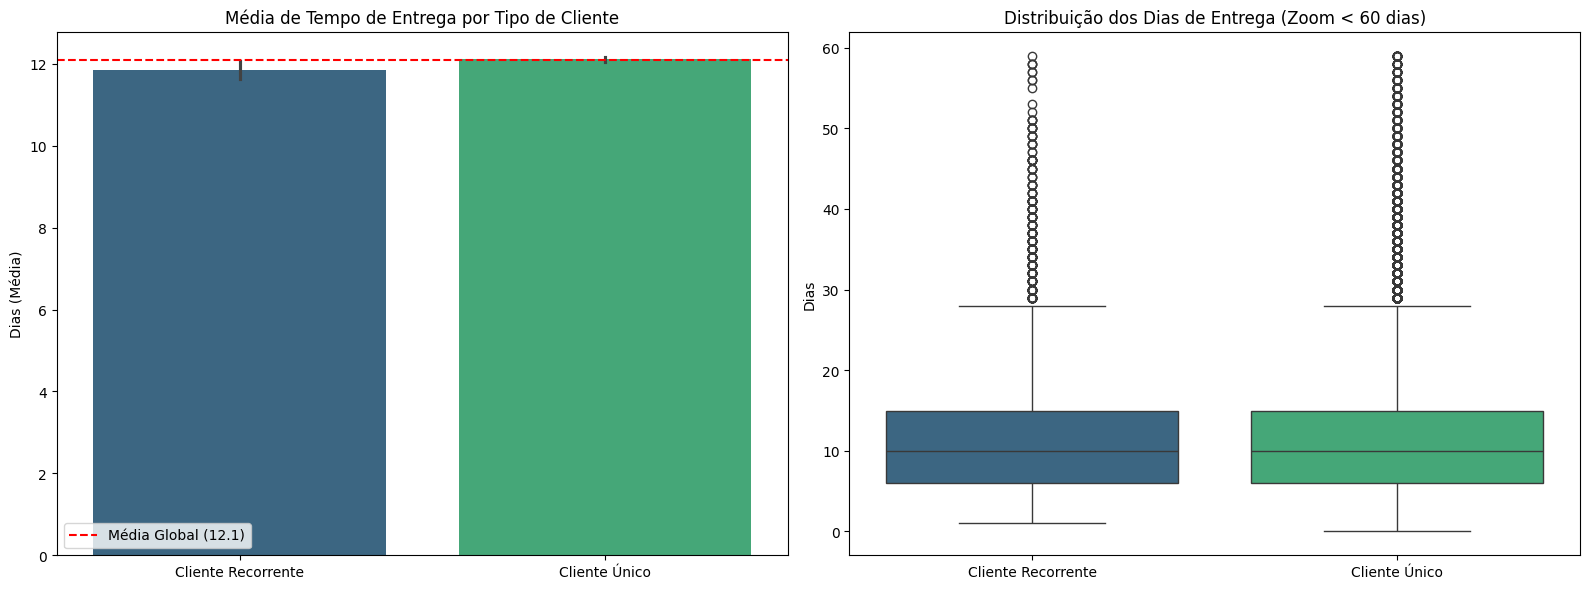

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. PREPARAÇÃO DOS DADOS
# ==============================================================================
# Supondo que você já carregou 'orders' e 'customers'
# Se não, descomente as linhas abaixo:
# orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
# customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')

# Converter datas
cols_data = ['order_purchase_timestamp', 'order_delivered_customer_date']
for col in cols_data:
    orders[col] = pd.to_datetime(orders[col])

# Merge para identificar os usuários únicos
df_eda = orders.merge(customers, on='customer_id', how='left')

# Filtro: Apenas pedidos entregues e com datas válidas
df_eda = df_eda[df_eda['order_status'] == 'delivered'].dropna(subset=['order_delivered_customer_date', 'order_purchase_timestamp'])

# --- CÁLCULO DA FEATURE: DIAS DE ENTREGA ---
df_eda['tempo_entrega_dias'] = (df_eda['order_delivered_customer_date'] - df_eda['order_purchase_timestamp']).dt.days

# --- DEFINIÇÃO DO TARGET (QUEM RECOMPROU?) ---
# Para esta EDA rápida, vamos considerar "Recompra" quem tem > 1 pedido na base total
contagem_pedidos = df_eda.groupby('customer_unique_id').size()
clientes_recorrentes = contagem_pedidos[contagem_pedidos > 1].index

df_eda['recomprou'] = df_eda['customer_unique_id'].isin(clientes_recorrentes).astype(int)
df_eda['status_cliente'] = df_eda['recomprou'].map({1: 'Cliente Recorrente', 0: 'Cliente Único'})

# ==============================================================================
# 2. ANÁLISE DE MÉDIAS
# ==============================================================================

# A. Média Global (Toda a base)
media_global = df_eda['tempo_entrega_dias'].mean()
mediana_global = df_eda['tempo_entrega_dias'].median()

print(f"--- ESTATÍSTICAS DE ENTREGA (BASE TOTAL) ---")
print(f"Média de Dias para Entrega: {media_global:.2f} dias")
print(f"Mediana de Dias para Entrega: {mediana_global:.2f} dias")

# B. Comparativo por Grupo
print(f"\n--- COMPARATIVO: RECORRENTE vs ÚNICO ---")
stats_por_grupo = df_eda.groupby('status_cliente')['tempo_entrega_dias'].agg(['mean', 'median', 'std', 'count'])
print(stats_por_grupo)

# ==============================================================================
# 3. VISUALIZAÇÃO GRÁFICA
# ==============================================================================

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Barplot (Média com Intervalo de Confiança)
sns.barplot(x='status_cliente', y='tempo_entrega_dias', data=df_eda, ax=ax[0], palette="viridis", errorbar=('ci', 95))
ax[0].set_title('Média de Tempo de Entrega por Tipo de Cliente')
ax[0].set_ylabel('Dias (Média)')
ax[0].set_xlabel('')
# Adicionar linha da média global
ax[0].axhline(media_global, color='red', linestyle='--', label=f'Média Global ({media_global:.1f})')
ax[0].legend()

# Gráfico 2: Boxplot (Distribuição e Outliers)
# Removemos outliers extremos (> 50 dias) só para visualizar melhor a "caixa" principal
sns.boxplot(x='status_cliente', y='tempo_entrega_dias', data=df_eda[df_eda['tempo_entrega_dias'] < 60], ax=ax[1], palette="viridis")
ax[1].set_title('Distribuição dos Dias de Entrega (Zoom < 60 dias)')
ax[1].set_ylabel('Dias')
ax[1].set_xlabel('')

plt.tight_layout()
plt.show()

--- RAIO-X DOS PRAZOS ---
Média Geral (Todos os pedidos): -11.88 dias
(Se negativo, significa que em média entrega ANTES do prazo)

--- QUANDO ATRASA, É GRAVE? ---
Taxa de Pedidos com Atraso: 6.77%
Média de dias de atraso (apenas dos atrasados): 10.62 dias

--- IMPACTO NA RECOMPRA (Médias) ---
                         mean  median        std
status_cliente                                  
Cliente Recorrente -12.651241   -13.0   9.814589
Cliente Único      -11.825189   -12.0  10.203676


/tmp/ipykernel_267649/925416660.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='status_cliente', y='erro_previsao_dias', data=df_eda, ax=ax[0], palette="magma", errorbar=('ci', 95))
/tmp/ipykernel_267649/925416660.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status_cliente', y='erro_previsao_dias', data=atrasados_apenas, ax=ax[1], palette="magma", showfliers=False)


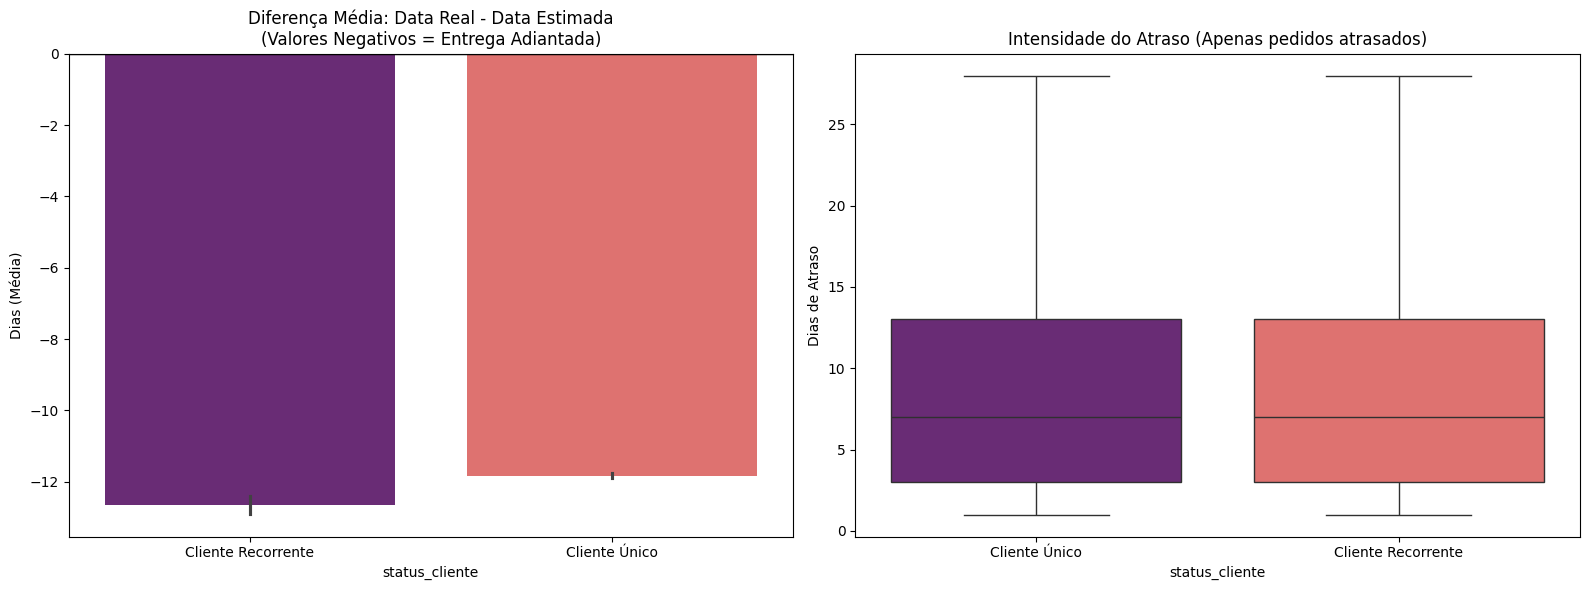

In [17]:
# ==============================================================================
# ANÁLISE ESPECÍFICA: ATRASOS (REAL vs ESTIMADO)
# ==============================================================================

# 1. Cálculo do Erro de Previsão (Dias)
# Positivo = ATRASOU | Negativo = ADIANTOU
df_eda['erro_previsao_dias'] = (df_eda['order_delivered_customer_date'] - df_eda['order_estimated_delivery_date']).dt.days

# 2. Estatísticas Gerais
media_erro = df_eda['erro_previsao_dias'].mean()
atrasados_apenas = df_eda[df_eda['erro_previsao_dias'] > 0]
media_dos_atrasados = atrasados_apenas['erro_previsao_dias'].mean()
percentual_atraso = len(atrasados_apenas) / len(df_eda) * 100

print(f"--- RAIO-X DOS PRAZOS ---")
print(f"Média Geral (Todos os pedidos): {media_erro:.2f} dias")
print(f"(Se negativo, significa que em média entrega ANTES do prazo)")
print(f"\n--- QUANDO ATRASA, É GRAVE? ---")
print(f"Taxa de Pedidos com Atraso: {percentual_atraso:.2f}%")
print(f"Média de dias de atraso (apenas dos atrasados): {media_dos_atrasados:.2f} dias")

# 3. Comparativo: Recompra vs Não Recompra
print(f"\n--- IMPACTO NA RECOMPRA (Médias) ---")
print(df_eda.groupby('status_cliente')['erro_previsao_dias'].agg(['mean', 'median', 'std']))

# 4. Visualização
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Média do Erro de Previsão (Mostra se entrega antes ou depois)
sns.barplot(x='status_cliente', y='erro_previsao_dias', data=df_eda, ax=ax[0], palette="magma", errorbar=('ci', 95))
ax[0].set_title('Diferença Média: Data Real - Data Estimada\n(Valores Negativos = Entrega Adiantada)')
ax[0].set_ylabel('Dias (Média)')
ax[0].axhline(0, color='black', linestyle='-', linewidth=1) # Linha do "Prazo Zero"

# Gráfico B: Apenas os Atrasados (Quem sofreu atraso, sofreu quanto?)
sns.boxplot(x='status_cliente', y='erro_previsao_dias', data=atrasados_apenas, ax=ax[1], palette="magma", showfliers=False)
ax[1].set_title('Intensidade do Atraso (Apenas pedidos atrasados)')
ax[1].set_ylabel('Dias de Atraso')

plt.tight_layout()
plt.show()

### R: **A vizualização dos dados e o teste de hipótese demosntras que variaveis logisticas não influenciam na recompra de um usuarios, sabendo disso vamos eliminar essas variaveis das features**

## Pilar B - Risco Logístico Regional